## Notebook 4: Advanced Non-Linear Embeddings & Manifold Learning

### 1. Imports and Loading Data

In [51]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import (StandardScaler, MinMaxScaler)
from sklearn.decomposition import (KernelPCA, NMF, PCA)
from sklearn.manifold import MDS

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

np.random.seed(24)
# stores the randomely generated data in seed 24

In [2]:
# Loading sample dataframe from notebook 3
df_sample = pd.read_csv('master_marketing_reduced.csv')

df_sample.head()

,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters,agg_clusters,db_clusters,ms_clusters,PC1,PC2,PC3,SVD1,SVD2,TSNE1,TSNE2
0,11906.880747,62427,0.021087,1263,10.701997,438.254852,18.194972,2,2,2,0,3,-3.115571,-0.349650,0.348304,-3.115571,-0.349650,-24.630646,0.633696
1,36306.065526,478661,0.041990,20999,1.742935,123.141463,21.936816,7,3,0,1,1,2.197341,-1.277466,0.415846,2.197341,-1.277466,35.280510,-9.395739
2,36039.772545,608496,0.038142,23702,1.476780,149.700788,23.916203,7,3,0,1,1,2.402865,-1.215359,0.675393,2.402865,-1.215359,28.861687,-5.731866
3,9182.470640,29637,0.017813,505,17.702593,475.003554,33.068893,2,2,2,0,3,-3.849713,-0.027592,0.520136,-3.849713,-0.027592,-36.812756,1.508232
4,39417.315326,635976,0.044160,29147,1.301943,60.987286,26.207460,7,3,0,1,1,3.269961,-1.188196,0.859188,3.269961,-1.188196,25.190420,0.824038


In [3]:
# Isolating the orignial 8 features in df
marketing_features = [
    'ad_budget', 'impressions', 'ctr', 'clicks', 'cpc', 'time_on_site', 'user_engagement_score', 'device_score'
]

features_only = df_sample[marketing_features]

df_scaled = StandardScaler().fit_transform(features_only)

print('Data Matrix loaded with shape:', df_scaled.shape)

Data Matrix loaded with shape: (1000, 8)


In [4]:
pd.DataFrame(df_scaled).head()

,0,1,2,3,4,5,6,7
0,-1.404559,-1.265423,-1.178770,-1.199519,0.763336,1.032962,-1.141610,-1.145306
1,0.618993,0.790390,0.961623,1.011447,-0.611252,-1.055955,-0.970608,1.222986
2,0.596908,1.431655,0.567588,1.314256,-0.652089,-0.879891,-0.880149,1.222986
3,-1.630508,-1.427376,-1.514017,-1.284436,1.837437,1.276572,-0.461871,-1.145306
4,0.877026,1.567381,1.183849,1.924244,-0.678914,-1.467981,-0.775439,1.222986


### 2. Kernal PCA

Standard PCA works brilliantly when our clusters can be separated by drawing straight lines or planes. But what happens if a cluster is wrapped tightly around another cluster (like a ring around a bullseye)? A straight line cannot cut between them.

**_Kernel PCA_** resolves this using a mathematical technique called the $Kernel Trick$.

1. The Feature Mapping: It takes our 8-dimensional data and projects it mathematically into a much higher, complex feature space (sometimes even an infinite-dimensional space).
2. The High-Dimensional View: In this new elevated space, the curved and twisted boundaries of your data naturally untangle and straighten out.
3. The Projection: It then runs standard linear PCA on that higher space and drops the flattened, cleanly separated coordinates back onto your 2D screen.

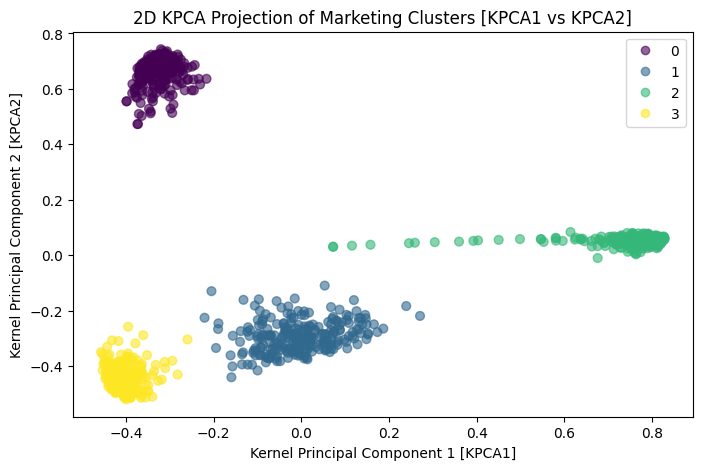

In [5]:
# Initilising Kernal PCA model
kpca_model = KernelPCA(
    n_components = 2,
    kernel = 'rbf',
    gamma = None,
    # gamma controls the width of the kernel (None defaults to 1 / n_features)
    random_state = 24
)

kpca_coordinates = kpca_model.fit_transform(df_scaled)

df_sample['KPCA1'] = kpca_coordinates[:, 0]
df_sample['KPCA2'] = kpca_coordinates[:, 1]

# Plotting the Kernel PCA Coordinates
plt.figure(figsize = (8,5))

scatter_kpca = plt.scatter(df_sample['KPCA1'], df_sample['KPCA2'], c = df_sample['clusters'], s = 40, alpha = 0.6)

plt.legend(*scatter_kpca.legend_elements(), loc = 'upper right')

plt.title('2D KPCA Projection of Marketing Clusters [KPCA1 vs KPCA2]')
plt.xlabel('Kernel Principal Component 1 [KPCA1]')
plt.ylabel('Kernel Principal Component 2 [KPCA2]')
plt.plot();

### 3. Multidimensional Scaling (MDS)

While **Kernel PCA** bends the space using infinite-dimensional mathematics, **MDS (Multidimensional Scaling)** focuses on a completely different, beautifully simple, distance-based rule.

MDS does not care about coordinates, variances, or kernel transformations. Its singular golden rule is: 'If Campaign A and Campaign B are exactly 4.2 units apart in the original 8D universe, they must remain as close to 4.2 units apart as possible on your flat 2D plot.

In MDS, parameter _metric_ has below features:
 - Metric MDS (`metric = True`): This is a rigid distance-preservation engine. It tries to match the absolute, literal geometric distance values between points. If a distance is 5.0, it wants it to be 5.0 on our screen.

 - Non-Metric MDS (`metric = False`): This is a more fluid, rank-based engine. It doesn't care about the exact numerical distance; it only cares about the order of distances. If Campaign A is our closest neighbour, and Campaign B is our furthest neighbour, it will warp the space to preserve that ranking.

MDS Optimization Stress Score: 66373.23 



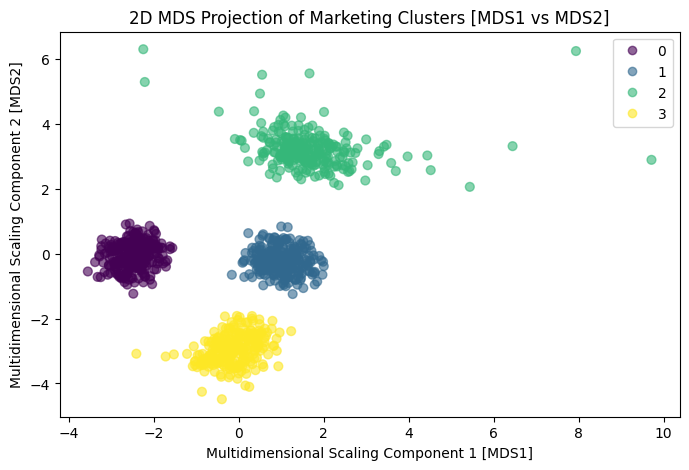

In [6]:
mds_model = MDS(
    n_components = 2,
    metric = True,
    max_iter = 300,
    eps = 1e-3,
    random_state = 24,
    n_init = 4,
    n_jobs = -1
)

mds_coordinates = mds_model.fit_transform(df_scaled)

df_sample['MDS1'] = mds_coordinates[:, 0]
df_sample['MDS2'] = mds_coordinates[:, 1]

# Stress test Score for MDS
print(f'MDS Optimization Stress Score: {mds_model.stress_:.2f} \n')

# Plotting the Kernel PCA Coordinates
plt.figure(figsize = (8,5))

scatter_mds = plt.scatter(df_sample['MDS1'], df_sample['MDS2'], c = df_sample['clusters'], s = 40, alpha = 0.6)

plt.legend(*scatter_mds.legend_elements(), loc = 'upper right')

plt.title('2D MDS Projection of Marketing Clusters [MDS1 vs MDS2]')
plt.xlabel('Multidimensional Scaling Component 1 [MDS1]')
plt.ylabel('Multidimensional Scaling Component 2 [MDS2]')
plt.plot();

**Key takeaway**

To contrast the infinite-dimensional warp maps of Kernel PCA, we executed a global Metric Multidimensional Scaling (MDS) projection. MDS focuses strictly on distance-preservation topology, optimising an error metric called **Stress** across all 499,500 unique pairwise campaign combinations.

Our optimization loop converged with a final raw Stress Score of **66,373.23**. The visual results yield brilliant architectural insights:

* **Return to Global Geometry:** Unlike the distorted, jellyfish-like manifolds generated by the RBF kernel, the MDS projection restores our four segments to clean, distinct, cloud-shaped distributions. This structural reversal mathematically proves that our underlying marketing personas are natively distributed as isotropic Gaussian clouds.


* **True Business Proximity:** Because Metric MDS is rigidly constrained to map accurate Euclidean distances, the spatial gaps between the four clouds on this plot represent the most honest, unwarped representation of how truly distinct these campaign profiles are in real operational terms.

### 4. NMF (Non-Negative Matrix FactoriSation)

Physically, **NMF** acts as a linear algebraic technique because it factorises our data into matrices that are multiplied straight together (X approx. W * H). However, it introduces a strict non-linear constraint: every single number in our matrices must be strictly _greater than or equal to zero_. There are absolutely no negative numbers allowed.

In [9]:
# Scaling the dataframe via MinMaxScaler to scale between 0 and 1

df_nmfscaled = MinMaxScaler().fit_transform(df_sample)

print('Data Matrix loaded with shape:', df_nmfscaled.shape)

Data Matrix loaded with shape: (1000, 23)


In [11]:
pd.DataFrame(df_nmfscaled).head()

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,0.214320,0.075855,0.227060,0.033057,0.143391,0.721637,0.117652,0.125,0.666667,0.666667,...,0.321528,0.311054,0.334109,0.321528,0.247611,0.515855,0.969656,0.441122,0.346464,0.702948
1,0.754070,0.620163,0.794000,0.588297,0.008029,0.179327,0.159870,0.750,1.000000,0.000000,...,0.142966,0.322013,0.839263,0.142966,0.935246,0.403432,0.030969,0.024271,0.291489,0.170226
2,0.748179,0.789947,0.689629,0.664341,0.004008,0.225036,0.182203,0.750,1.000000,0.000000,...,0.154919,0.364124,0.858804,0.154919,0.861574,0.444502,0.025114,0.033295,0.271809,0.147275
3,0.154051,0.032976,0.138261,0.011732,0.249163,0.784881,0.285471,0.125,0.666667,0.666667,...,0.383510,0.338934,0.264307,0.383510,0.107790,0.525658,0.974757,0.463044,0.454954,0.704895
4,0.822896,0.825883,0.852862,0.817527,0.001366,0.072360,0.208055,0.750,1.000000,0.000000,...,0.160147,0.393945,0.941248,0.160147,0.819436,0.517988,0.062111,0.072179,0.281173,0.072426


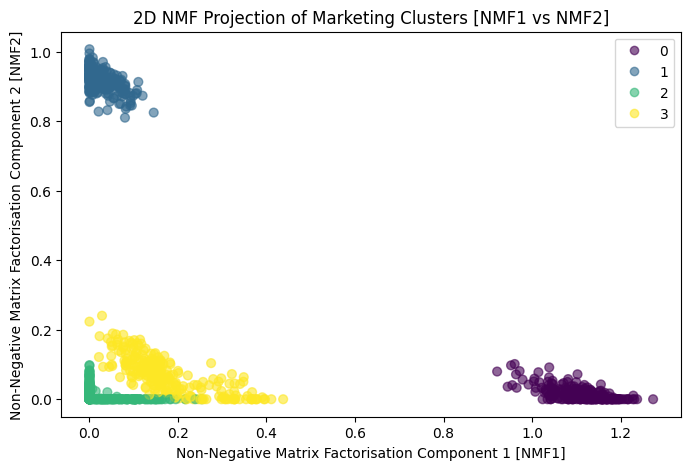

In [24]:
# Initiating NMF to find 4 hidden components
nmf_model = NMF(
    n_components = 4,
    init = 'random',
    random_state = 24,
    max_iter = 1000
)

nmf_coordinates = nmf_model.fit_transform(df_nmfscaled)

df_sample['NMF1'] = nmf_coordinates[:, 0]
df_sample['NMF2'] = nmf_coordinates[:, 1]
# assigning each row to component with highest score
df_sample['nmf_clusters'] = np.argmax(nmf_coordinates, axis = 1)

# Plotting the NMF coordinates
plt.figure(figsize = (8,5))

scatter_nmf = plt.scatter(df_sample['NMF1'], df_sample['NMF2'], c = df_sample['nmf_clusters'], s = 40, alpha = 0.6)

plt.legend(*scatter_nmf.legend_elements(), loc = 'upper right')

plt.title('2D NMF Projection of Marketing Clusters [NMF1 vs NMF2]')
plt.xlabel('Non-Negative Matrix Factorisation Component 1 [NMF1]')
plt.ylabel('Non-Negative Matrix Factorisation Component 2 [NMF2]')
plt.plot();

### 5. Comparing ALL Non-Linear Embeddings on the Butterfly Image

Original Image Shape: (1080, 1920, 3)
Matrix Length of Original Image: 3


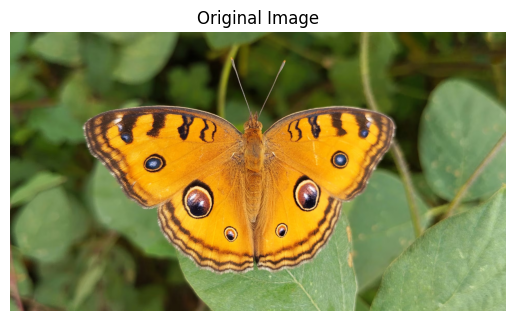

In [32]:
# Loading the image from local folder

raw_img = plt.imread('butterfly.png')

print('Original Image Shape:', raw_img.shape)
print('Matrix Length of Original Image:', len(raw_img.shape))
plt.title('Original Image')
plt.imshow(raw_img)
plt.axis('off');

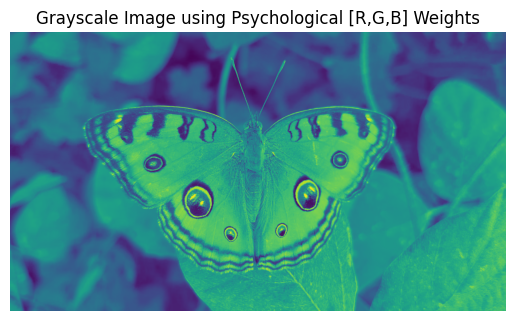

In [47]:
# Converting to grayscale since image is in color
if len(raw_img.shape) == 3:
    # Standard psychological weights for human perception of Red, Green, and Blue
    gray_img = 0.2989 * raw_img[:, :, 0] + 0.5870 * raw_img[:, :, 1] + 0.1140 * raw_img[:, :, 2]
else:
    gray_img = raw_img.copy()

plt.imshow(gray_img)
plt.title('Grayscale Image using Psychological [R,G,B] Weights')
plt.axis('off');

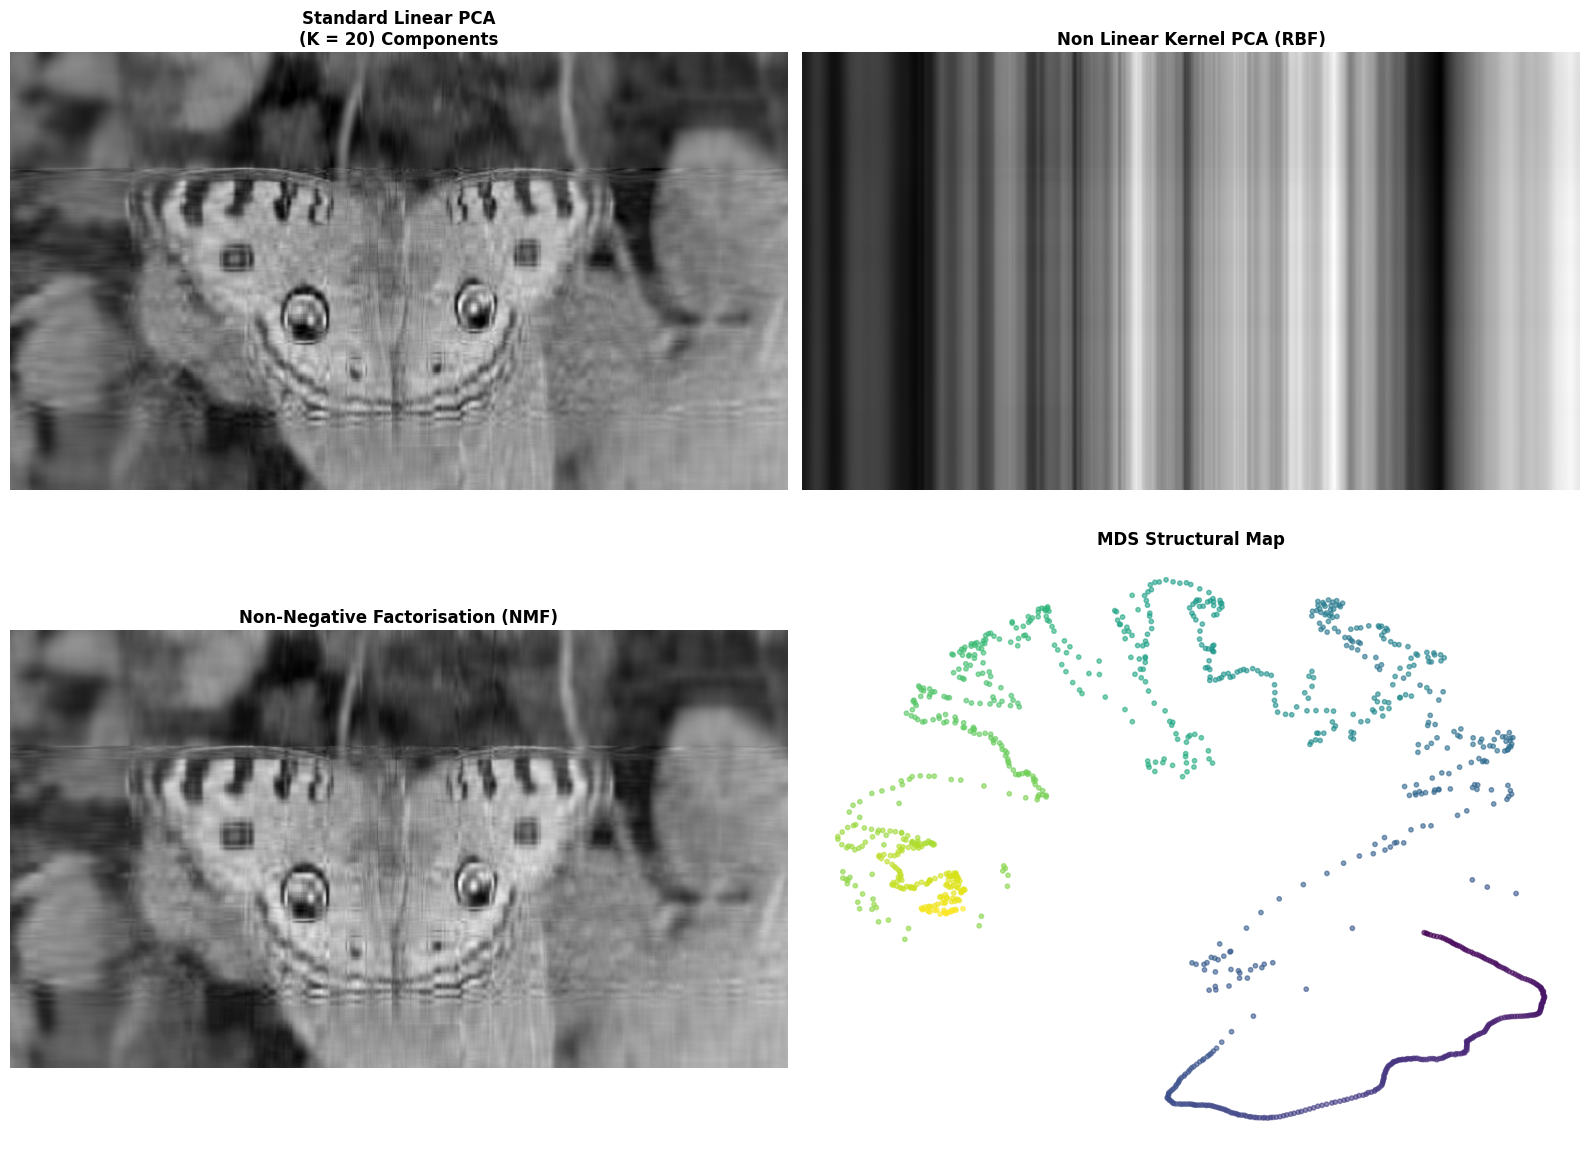

In [75]:
# Ensuring image matrix has floating point decimals for smooth plotting
gray_img = gray_img.astype(np.float64)

# Setting evaluation dimension count (e.g. 20 components)
k = 20

# Setting 1x4 plot grid
fig, ax = plt.subplots(2, 2, figsize = (16,12))
ax = ax.flatten()

# Method 1: Linear base PCA
pca_base = PCA(
    n_components = k,
    random_state = 24
)

pca_img = pca_base.inverse_transform(pca_base.fit_transform(gray_img))
ax[0].imshow(np.clip(pca_img, 0, 255), cmap = 'gray')
ax[0].set_title(f'Standard Linear PCA\n(K = {k}) Components', fontweight = 'bold')

# Method 2: Non-Linear Warp (Kernel PCA)
kpca_base = KernelPCA(
    n_components = k,
    kernel = 'rbf',
    fit_inverse_transform = True,
    random_state = 24
)

kpca_img = kpca_base.inverse_transform(kpca_base.fit_transform(gray_img))
ax[1].imshow(np.clip(kpca_img, 0, 255), cmap = 'gray')
ax[1].set_title('Non Linear Kernel PCA (RBF)', fontweight = 'bold')

# Method 3: Non-Negative Part Extraction (NMF)
# Scaling image to 0-1 for NMF
gray_img_norm = gray_img / 255.0
nmf_base = NMF(
    n_components = k,
    init = 'random',
    random_state = 24,
    max_iter = 500
)

W = nmf_base.fit_transform(gray_img_norm)
H = nmf_base.components_
nmf_img = np.dot(W, H) * 255.0 # reconstructing image from positive pieces
ax[2].imshow(np.clip(nmf_img, 0, 255), cmap = 'gray')
ax[2].set_title('Non-Negative Factorisation (NMF)', fontweight = 'bold')

# Method 4:Distance Based Grid (MDS)
mds_base = MDS(
    n_components = 2,
    metric = True,
    max_iter = 100,
    random_state = 24
)

pixel_rows_2d = mds_base.fit_transform(gray_img)
ax[3].scatter(pixel_rows_2d[:, 0], pixel_rows_2d[:, 1], c = np.arange(len(gray_img)), s = 10, alpha = 0.6)
ax[3].set_title('MDS Structural Map', fontweight = 'bold')

for axes in ax.flatten():
    axes.axis('off')

plt.tight_layout()
plt.show();

### 6. Cluster Comparison

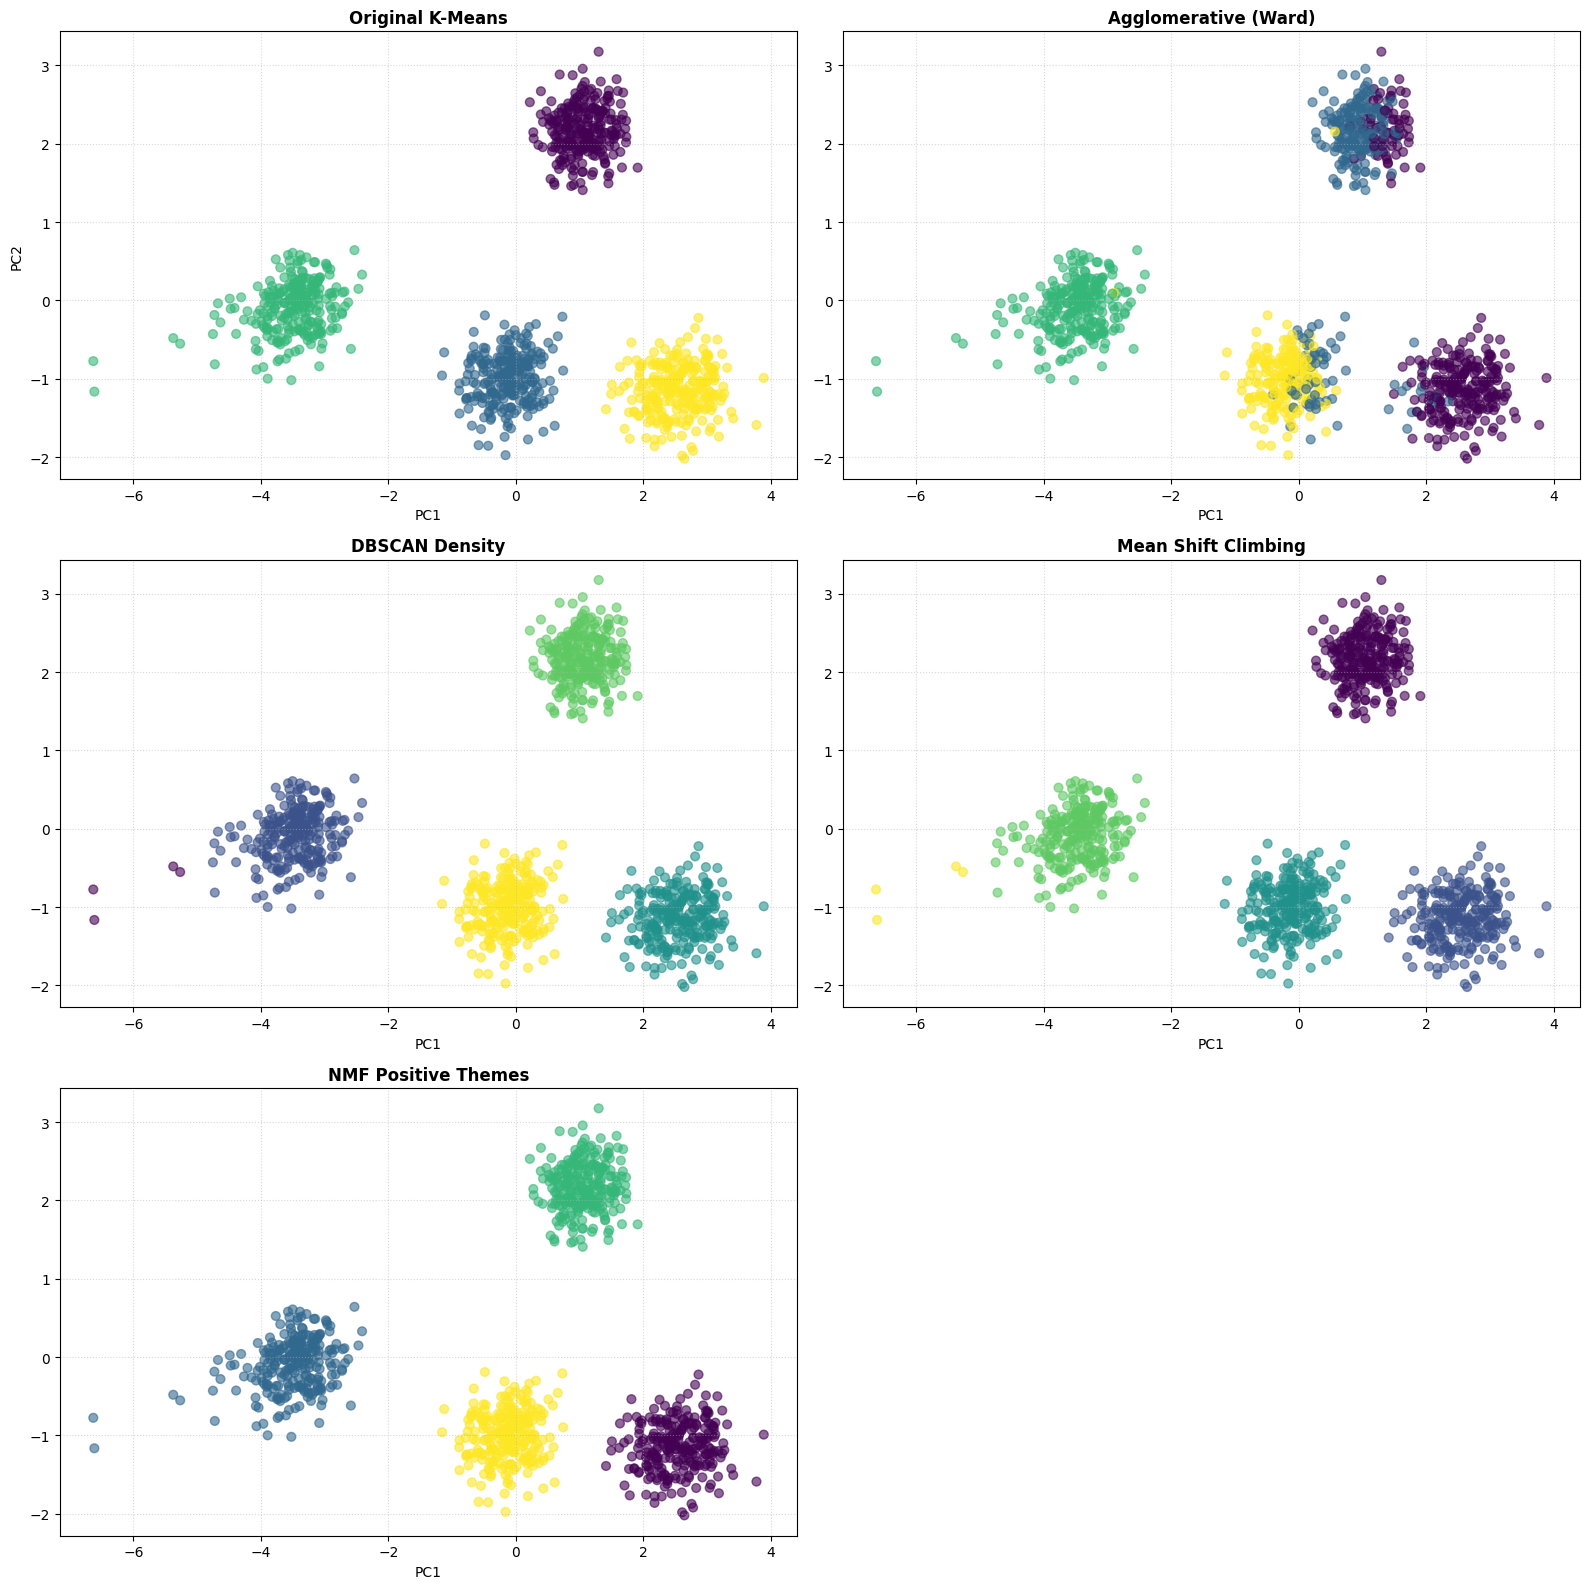

In [76]:
cluster_columns = ['clusters', 'agg_clusters', 'db_clusters', 'ms_clusters', 'nmf_clusters']
titles = ['Original K-Means', 'Agglomerative (Ward)', 'DBSCAN Density', 'Mean Shift Climbing', 'NMF Positive Themes']

fig, axes = plt.subplots(3, 2, figsize = (16,16))
ax = axes.flatten()

for idx, col in enumerate(cluster_columns):
    if col in df_sample.columns:

        ax[idx].scatter(df_sample['PC1'], df_sample['PC2'], c = df_sample[col], alpha = 0.6, s = 40)

        ax[idx].set_title(titles[idx], fontweight = 'bold')
        ax[idx].set_xlabel('PC1')
        
        if idx == 0:
            ax[idx].set_ylabel('PC2')
        ax[idx].grid(linestyle = ':', alpha = 0.5)
        ax[idx].axis('on')

ax[5].set_visible(False)
plt.tight_layout()
plt.show();

In [78]:
# Save the increased sample containing marketing features, clustering labels, PCA, and t-SNE coordinates
df_sample.to_csv("final_marketing_reduced.csv", index=False)